In [1]:
# import required libraries
from pathlib import Path
from IPython.display import Markdown as md
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline






# 1) Data Analysis and Preparation

The task resembles the problem feature selection where features containing little to no information are dropped in order to reduce complexity and thereby computation time. Other advantages include a performance increase that may occur depending on the choice of selected features performance and the model is less likely to overfit.

My approach to the ranking problem laid out in the following is split into:

1) Statistical and graphical data analysis preparation<br>
2) Ranking methods <br>
&emsp; 2.1) Coefficients of Logistic Regression <br>
&emsp; 2.2) Exploiting sklearn's SelectFromModel (combined with LinearSVC)<br>
&emsp; 2.3) Random Forests <br>
&emsp; 2.4) Permutation Importance vs Random Forest Feature Importance (MDI) <br>
&emsp;&emsp;&emsp; a) on the original dataset<br>
&emsp;&emsp;&emsp; b) with the addition of an artificial sensor with random values from the uniform distribution in between 0 and 1 <br>
&emsp;&emsp;&emsp; c) with the addition of an artificial sensor with random values from the Gaussian normal distribution

# 1.1) Load data

First, the sensor data is loaded and explored. Information such as the 'sample index' is dropped because this information is also given by the indices.

In [2]:
# read data and save as df
project_root = Path('.')
df = pd.read_csv(project_root / 'data' / 'task_data.csv')
# drop redundant information (indices)
df = df.drop(labels='sample index', axis=1)
# safety copy df
df_copy = df.copy()

# Original Sensor Samples
df

,class_label,sensor0,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9
0,1.0,0.834251,0.726081,0.535904,0.214896,0.873788,0.767605,0.111308,0.557526,0.599650,0.665569
1,1.0,0.804059,0.253135,0.869867,0.334285,0.604075,0.494045,0.833575,0.194190,0.014966,0.802918
2,1.0,0.694404,0.595777,0.581294,0.799003,0.762857,0.651393,0.075905,0.007186,0.659633,0.831009
3,1.0,0.783690,0.038780,0.285043,0.627305,0.800620,0.486340,0.827723,0.339807,0.731343,0.892359
4,1.0,0.788835,0.174433,0.348770,0.938244,0.692065,0.377620,0.183760,0.616805,0.492899,0.930969
...,...,...,...,...,...,...,...,...,...,...,...
395,-1.0,0.433150,0.816109,0.452945,0.065469,0.237093,0.719321,0.577969,0.085598,0.357115,0.070060
396,-1.0,0.339346,0.914610,0.097827,0.077522,0.484140,0.690568,0.420054,0.482845,0.395148,0.438641
397,-1.0,0.320118,0.444951,0.401896,0.970993,0.960264,0.138345,0.354927,0.230749,0.204612,0.558889
398,-1.0,0.059132,0.337426,0.772847,0.099038,0.966042,0.975086,0.532891,0.035839,0.258723,0.709958


The given data includes 400 labeled sample readings for 10 different sensors. Binary classification with classes "1" and "-1"

## 1.2) Data Analysis

The data is explored for significant information within descriptive statistics (count, mean, std), min, max,...).

,class_label,sensor0,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.000000,0.523661,0.509223,0.481238,0.509752,0.497875,0.501065,0.490480,0.482372,0.482822,0.541933
std,1.001252,0.268194,0.276878,0.287584,0.297712,0.288208,0.287634,0.289954,0.282714,0.296180,0.272490
min,-1.000000,0.007775,0.003865,0.004473,0.001466,0.000250,0.000425,0.000173,0.003322,0.003165,0.000452
25%,-1.000000,0.299792,0.283004,0.235544,0.262697,0.249369,0.269430,0.226687,0.242848,0.213626,0.321264
50%,0.000000,0.534906,0.507583,0.460241,0.510066,0.497842,0.497108,0.477341,0.463438,0.462251,0.578389
75%,1.000000,0.751887,0.727843,0.734937,0.768975,0.743401,0.738854,0.735304,0.732483,0.740542,0.768990
max,1.000000,0.999476,0.998680,0.992963,0.995119,0.999412,0.997367,0.997141,0.998230,0.996098,0.999465


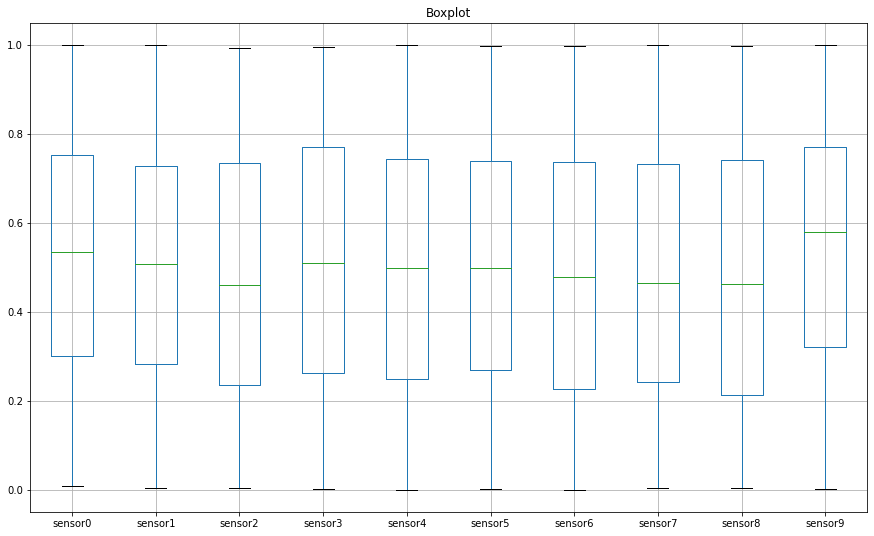

In [3]:
# boxplot dataset
df.filter(regex = 'sensor*').boxplot(figsize=(15,9))
plt.title('Boxplot')

# descriptive statistics (count, mean, std), min, max,...) of dataset
df.describe()

- The dataset is complete (no missing values). 
- Sensor range is a float in between 0 and 1.
- Mean, standard deviation and median (50% quantile) have no significant outliers with respect to the sensors: mean$\approx0.5$, std$\approx0.28$ and median$\approx0.5$

In [4]:
# check if the classes are balanced
df.groupby('class_label').count()

,sensor0,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9
class_label,,,,,,,,,,
-1.0,200,200,200,200,200,200,200,200,200,200
1.0,200,200,200,200,200,200,200,200,200,200


- The classes are balanced within the given dataset.

,sensor0,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9
sensor0,1.000000,0.215668,0.019521,0.253244,0.300760,0.164243,0.007849,0.080306,0.361751,0.001317
sensor1,0.215668,1.000000,0.056042,0.111347,0.130463,0.055401,0.106082,0.031513,0.163818,0.023655
sensor2,0.019521,0.056042,1.000000,0.093447,0.023486,0.008948,0.057090,0.006899,0.008308,0.058528
sensor3,0.253244,0.111347,0.093447,1.000000,0.295136,0.038152,0.105005,0.001243,0.287776,0.013732
sensor4,0.300760,0.130463,0.023486,0.295136,1.000000,0.183916,0.022690,0.090186,0.378306,0.023776
sensor5,0.164243,0.055401,0.008948,0.038152,0.183916,1.000000,0.061238,0.020814,0.220014,0.071258
sensor6,0.007849,0.106082,0.057090,0.105005,0.022690,0.061238,1.000000,0.065211,0.073309,0.040744
sensor7,0.080306,0.031513,0.006899,0.001243,0.090186,0.020814,0.065211,1.000000,0.060028,0.059341
sensor8,0.361751,0.163818,0.008308,0.287776,0.378306,0.220014,0.073309,0.060028,1.000000,0.033991
sensor9,0.001317,0.023655,0.058528,0.013732,0.023776,0.071258,0.040744,0.059341,0.033991,1.000000


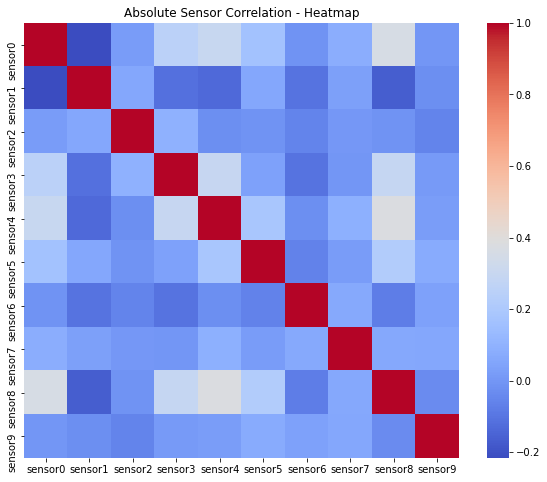

In [5]:
# correlation matrix
corr = df.filter(regex='sensor*').corr()
# check for absolute correlation (Equal importance 
# of positive and negative correlation)
abs_corr = corr.copy().abs()

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', square=True, ax=ax)
plt.title('Absolute Sensor Correlation - Heatmap')

abs_corr.style.background_gradient(cmap='coolwarm', axis=None)

No sensors exhibit a high correlation to another (correlation$\leq0.378306$ for all sensor pairs)

In [6]:
var = df.filter(regex='sensor*').var()
abs_corr.style.background_gradient(cmap='coolwarm', axis=None)

,sensor0,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,sensor9
sensor0,1.000000,0.215668,0.019521,0.253244,0.300760,0.164243,0.007849,0.080306,0.361751,0.001317
sensor1,0.215668,1.000000,0.056042,0.111347,0.130463,0.055401,0.106082,0.031513,0.163818,0.023655
sensor2,0.019521,0.056042,1.000000,0.093447,0.023486,0.008948,0.057090,0.006899,0.008308,0.058528
sensor3,0.253244,0.111347,0.093447,1.000000,0.295136,0.038152,0.105005,0.001243,0.287776,0.013732
sensor4,0.300760,0.130463,0.023486,0.295136,1.000000,0.183916,0.022690,0.090186,0.378306,0.023776
sensor5,0.164243,0.055401,0.008948,0.038152,0.183916,1.000000,0.061238,0.020814,0.220014,0.071258
sensor6,0.007849,0.106082,0.057090,0.105005,0.022690,0.061238,1.000000,0.065211,0.073309,0.040744
sensor7,0.080306,0.031513,0.006899,0.001243,0.090186,0.020814,0.065211,1.000000,0.060028,0.059341
sensor8,0.361751,0.163818,0.008308,0.287776,0.378306,0.220014,0.073309,0.060028,1.000000,0.033991
sensor9,0.001317,0.023655,0.058528,0.013732,0.023776,0.071258,0.040744,0.059341,0.033991,1.000000


Features with low variance can often be discarded. However, this dataset is rather small and high or low variance can also be randomly induced. 

- Sensor 2 has the lowest variance
- Sensors 6, 7 and 9 also have generally lower variance than the others

Variance based feature dropping of one or more of the mentioned sensors could be done and the reduced models' performance compared.

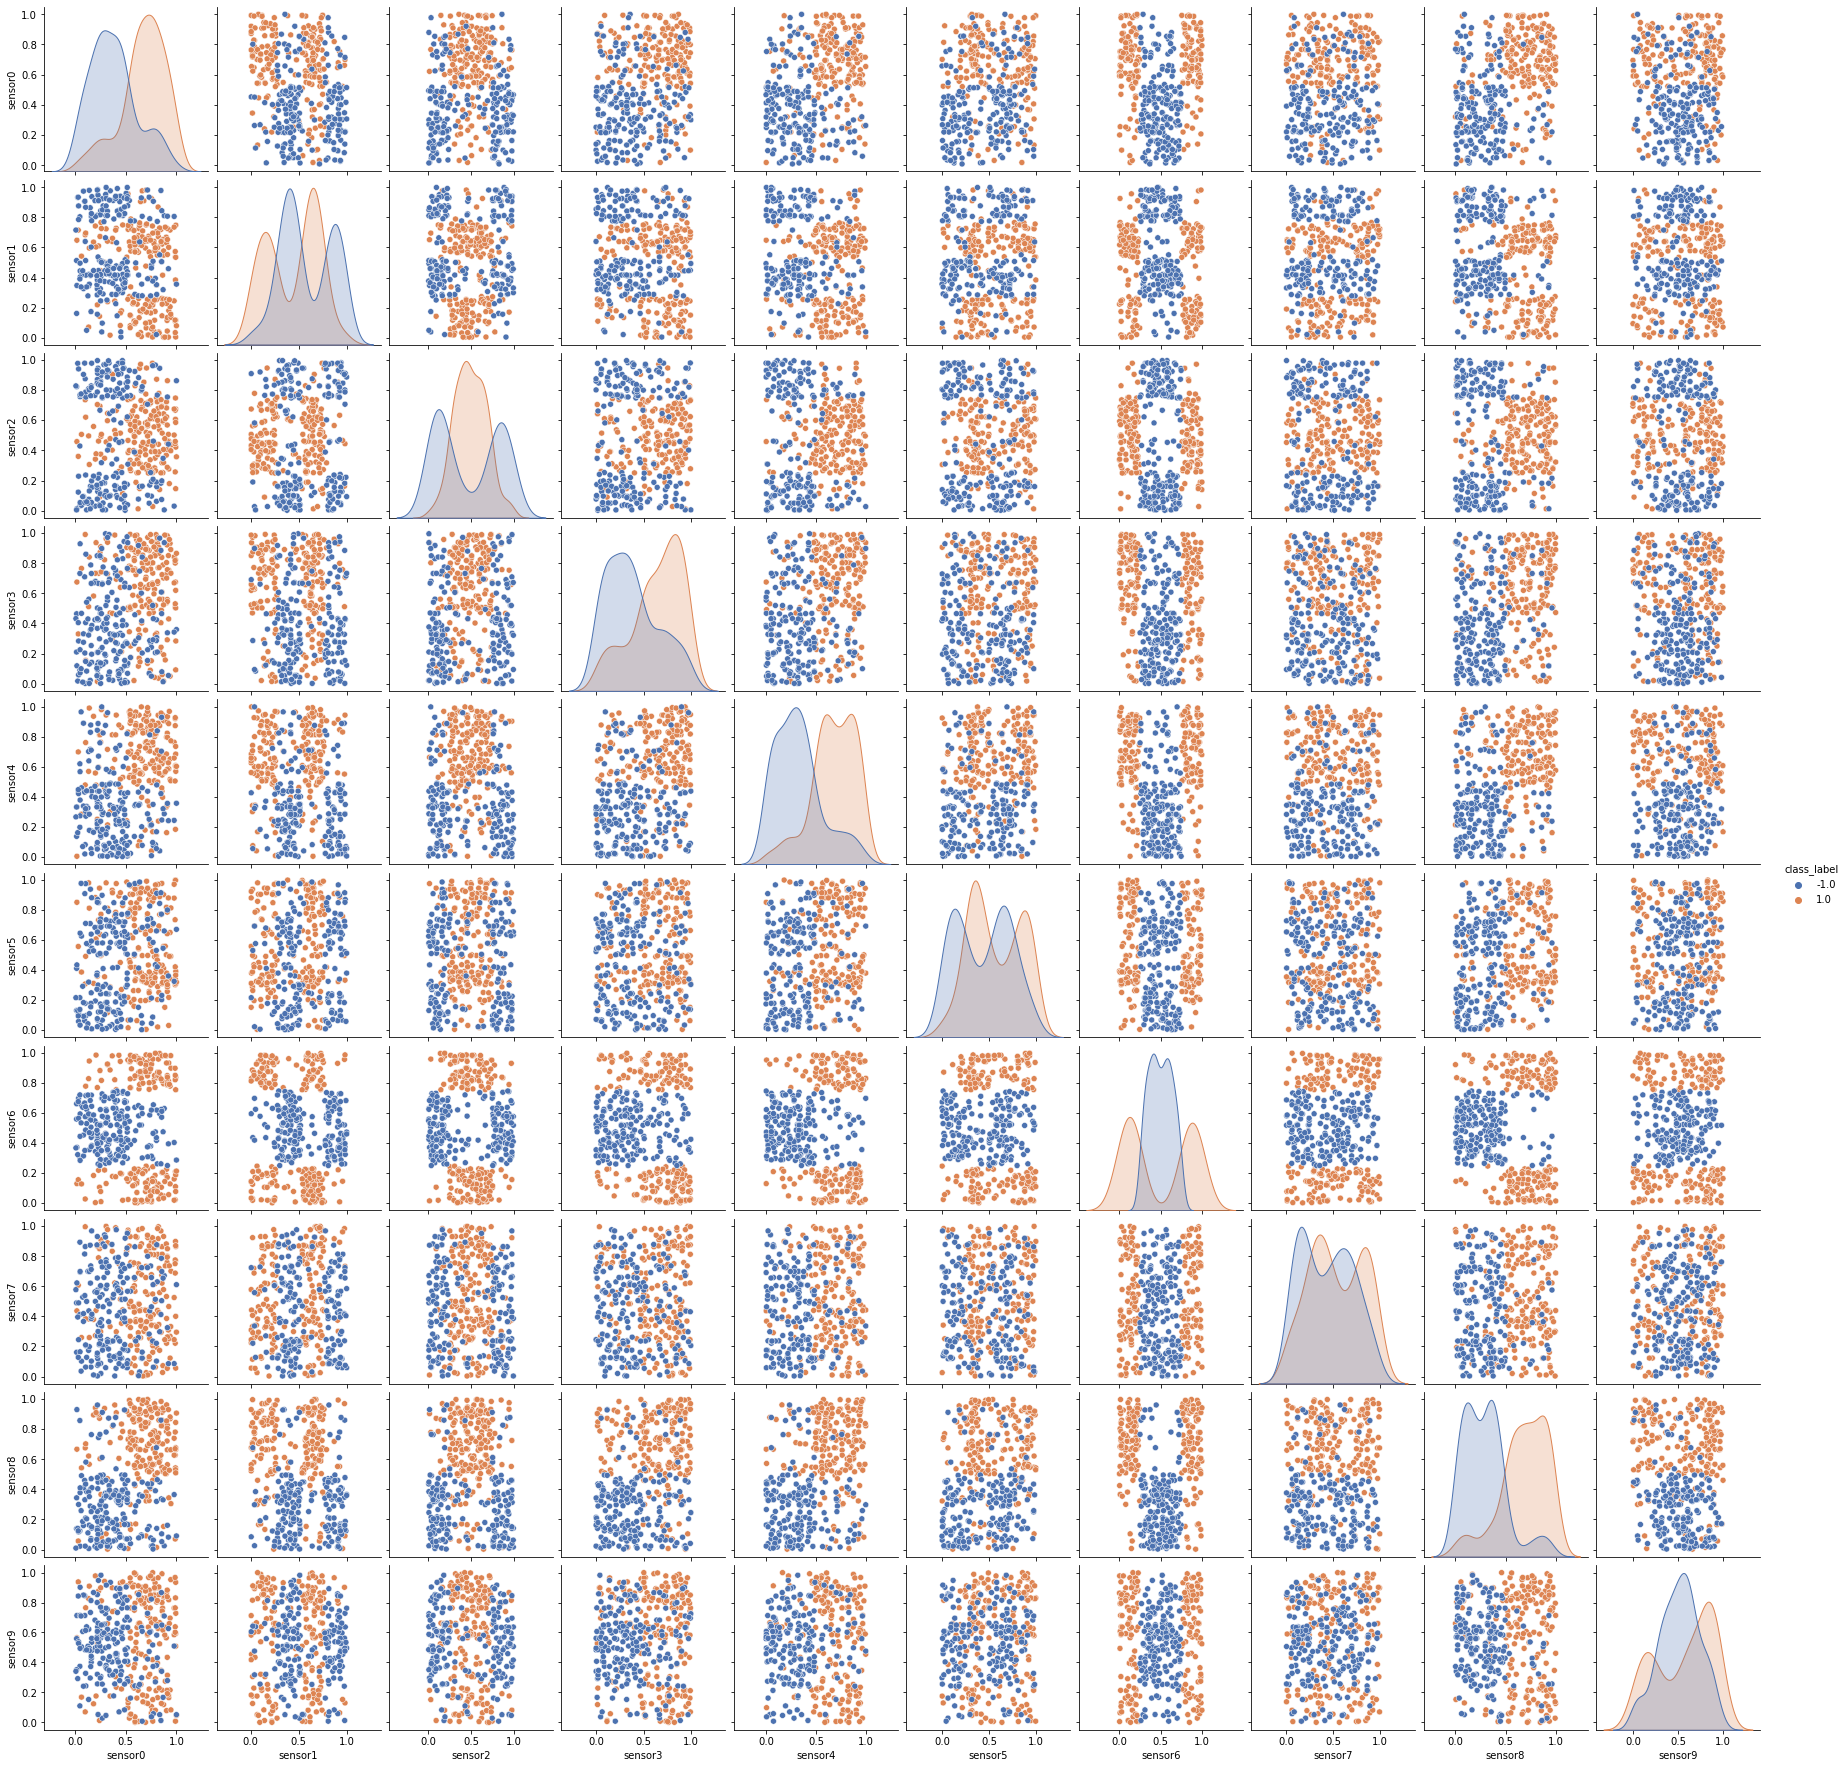

In [7]:
# Scatter plot/Pair plot
sns.pairplot(df, hue='class_label', palette='deep')

There are some takeaways from the pairwise scatter plots.

Some sensors (e.g. 2, 4, 6 and 8) appear to reveal high much information depending directly on its value. 

However, there are some that show an almost clean split at sensor values of about $0.5$ (compare sensor8). Others appear to approximately split different intervals of sensor values to different class labels (e.g sensor6 or sensor1 to an even higher degree).

Then there's also sensors that do not allow label categorizations by intervals of its value (compare sensor5 and sensor7).

Depending on the choice of the model this can have implications on the importance of the respective sensors:

Assuming a simple model of linear or logistic regression, sensor8 would probably be valued more important than sensor6 because there the shape of the linear or logistic function allows for a cleaner split of the two classes data points.


# 2) Sensor Ranking by Importance

## 2.1) Logistic Regression (rank by feature coefficient)

In a first approach, a logistic regression (LogReg) model is fitted on a random stratified training set (90% of the data).

Following the understanding of the coefficients of logistic regression "we can interpret a coefficient as the amount of evidence provided per change in the associated predictor. (https://towardsdatascience.com/understanding-logistic-regression-coefficients-7a719ebebd35)".
This allows to account the absolute coefficients as an approximate measure of feature importance. 

In [8]:
# extract column names
columns = list(df.columns)

# declare x (sensor values) and y (class labels)
y = df['class_label'].values
x = df.loc[:, columns[1:]].values

# create stratified test partition (10% of the cases)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=.1,
    stratify=y)

# test if stratified
unique, count = np.unique(y_test, return_counts=True)
# test if test partition contains 20 samples for each class
assert unique.tolist() == [-1, 1]
assert count.tolist() == [20, 20]

# logistic regression
clf = LogisticRegression().fit(x_train, y_train)

# coefficients
print(clf.coef_)

# mean accuracy
clf.score(x_test, y_test)

[[ 2.63347951 -1.13335563  0.51658953  2.01394406  3.22881914  0.40225797
   0.28199458  1.16211009  4.00155008  1.04877561]]


0.975

In [9]:
md("The coefficients can be extracted and the model's R-squared score is relatively good: {}".format(clf.score(x_test, y_test)))

The coefficients can be extracted and the model's R-squared score is relatively good: 0.975

,logRegCoef,absLogRegCoef
sensor8,4.001550,4.001550
sensor4,3.228819,3.228819
sensor0,2.633480,2.633480
sensor3,2.013944,2.013944
sensor7,1.162110,1.162110
sensor1,-1.133356,1.133356
sensor9,1.048776,1.048776
sensor2,0.516590,0.516590
sensor5,0.402258,0.402258
sensor6,0.281995,0.281995


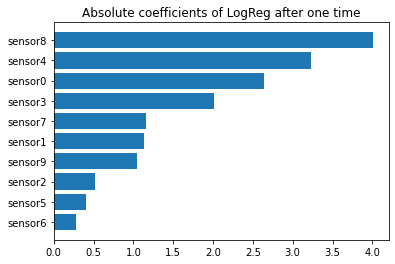

In [10]:
# suppose high coefficient is a measurement for importance
feature_coef = {}
for (feature, coef) in zip(columns[1:], clf.coef_[0]):
    feature_coef[feature] = coef


# sort by coefficients
# convert back to df
feature_df = pd.DataFrame.from_dict(
    feature_coef, orient='index', columns=['logRegCoef'])
feature_df['absLogRegCoef'] = feature_df['logRegCoef'].abs()
feature_df_sorted_abs_coef = feature_df.sort_values(
    by=['absLogRegCoef'], ascending=False)

rankingLogReg = list(feature_df_sorted_abs_coef.index)

# plot
f, ax = plt. subplots()
ax.barh(feature_df_sorted_abs_coef.index, feature_df_sorted_abs_coef["absLogRegCoef"])
plt.title("Absolute coefficients of LogReg after one time")
plt.gca().invert_yaxis()

# Sensor ranking after 1-time logistic regression 
# with random stratified test set ()
feature_df_sorted_abs_coef

## Multiple draws and fits to test how LogReg performs on average

Since the dataset is rather small (400 samples) and LogReg is stochastic, further evaluation may be necessary.

The LogReg performance is further checked on a reduced set of features. In each iteration the feature with the lowest coefficient is dropped.

Moreover, in each iteration a number of ```tries=40``` different training sets are drawn in order to determine the accuracy on average. 

[('8.4.0.3.7.1.9.2.5.6', 0.938125),
 ('8.4.0.3.7.1.9.2.5', 0.9206249999999997),
 ('8.4.0.3.7.1.9.2', 0.9300000000000003),
 ('8.4.0.3.7.1.9', 0.9281250000000002),
 ('8.4.0.3.7.1', 0.90625),
 ('8.4.0.3.7', 0.9124999999999996),
 ('8.4.0.3', 0.9156249999999998),
 ('8.4.0', 0.9049999999999999),
 ('8.4', 0.874375),
 ('8', 0.875625)]

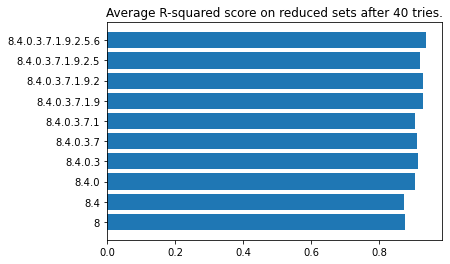

In [11]:
# The dataset (400 samples) is rather small.
# Logistic regression is a stochastic.
# => Review its performance on reduced sets of features
# multiple draws and fits to see how the model performs

def reduce_and_test_logReg(ranking, df):
    # generate a smaller feature set
    y = df['class_label'].values
    x = df.loc[:, ranking].values

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.1,
        stratify=y
    )
    # fit
    clf = LogisticRegression().fit(x_train, y_train)
    # get score
    score = clf.score(x_test, y_test)

    return score

tries = 40
# save accuracy in array
a = np.zeros(shape=(tries, len(rankingLogReg)))
for i in range(a.shape[0]):
    # save checked sets
    l = []
    for j in range(a.shape[1]):
        # reduce set
        # drop features with lower coefficients first
        if j == 0:
            ranks = rankingLogReg[:]
        else: 
            ranks = rankingLogReg[:(-j)]

        l.append(ranks)
        a[i, j] = reduce_and_test_logReg(ranking=ranks, df=df_copy)
        
        
# calculate average accuracy on different trainings sets
groups = ['.'.join(feature_set).replace('sensor', '') for feature_set in l]
avg_acc = np.sum(a, axis=0)/tries
avg_acc = avg_acc.tolist()

avg_group_acc = list(zip(groups, avg_acc))

# plot
f, ax = plt.subplots()
ax.barh(groups, avg_acc)
plt.gca().invert_yaxis()
plt.title(f'Average R-squared score on reduced sets after {tries} tries.')

avg_group_acc

In [12]:
# transform to percentage and round
def topercent(x):
    return round(x*100, 2)

md("Highest ('{}'; R²={}%) and lowest ('{}'; R²={}%) R-squared performance are {}% apart.\n\n Reducing to the best 4 sensors ('{}') yields R²={}%. \n\n Adding sensor 7 alone changes the performance by {}% leading to R²={}% \n\n With yet another additional sensor the model performance is {}% lower than the maximum, yielding: '{}', R²={}%".format(
    groups[np.argmax(avg_acc)],
    topercent(np.amax(avg_acc)),
    groups[np.argmin(avg_acc)],
    topercent(np.amin(avg_acc)),
    topercent(np.amax(avg_acc)-np.amin(avg_acc)),
    
    groups[6],
    topercent(avg_acc[6]),
    
    topercent(avg_acc[6]-avg_acc[5]),
    topercent(avg_acc[5]),
    
    topercent(np.amax(avg_acc)-avg_acc[4]),
    groups[4],
    topercent(avg_acc[4])
))

Highest ('8.4.0.3.7.1.9.2.5.6'; R²=93.81%) and lowest ('8.4'; R²=87.44%) R-squared performance are 6.37% apart.

 Reducing to the best 4 sensors ('8.4.0.3') yields R²=91.56%. 

 Adding sensor 7 alone changes the performance by 0.31% leading to R²=91.25% 

 With yet another additional sensor the model performance is 3.19% lower than the maximum, yielding: '8.4.0.3.7.1', R²=90.62%

It is shown that in this setup sensors can be dropped without significant performance loss. Depending on which sensors are left out, the performance even slightly increases.

The small distance from best to worst performance could mean that best sensor describes the system well, and the others only add little information to the problem. Also possible is that another model than Logistic Regression may be a better model.




##  2.2) SelectFromModel() with LinearSVC Model

A second approach exploits ```SelectFromModel()``` (https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html). The idea is to iterate over SelecFromModel() by handing different values of ```threshold``` and then create a ranking after each sensor has been selected.

Here a quick and by far not optimized parametrized ```threshold```-iteration is shown. Following the path on https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html, Linear Support Vector Classification (LinearSVC) is chosen as the estimator. The LinearSVC model also introduces a regularization hyperparameter ```C```. Lower values prefer regularized fits. Here it is chosen ```C=0.01```. In Machine Learning, regularization is often prefered. Apart from therefore being chosen to represent a low value however, ```C``` was chosen arbitrarily and the ranking algorithm parametrized accordingly (by choice of initial threshold ```init_threshold=0.51``` and multiplier of ```i```,  ```multi=0.0004```.

In [13]:
sensor = []
init_threshold = 0.51
multi = 0.0004
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
# in case 2 or more sensore were dropped at one iteration start again
while len(sensor) != 10:
    sensor = []
    # fit SelectFromModel
    pipe = make_pipeline(SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold))
    pipe.fit(x_train, y_train)
    #selector = SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold).fit(x_train, y_train)
    
    # check if sensor is selected
    support = pipe.steps[0][1].get_support()
    # first sensor choice
    sensor_iter = [i for i, val in enumerate(support) if val] 
    #print("First: ", sensor_iter)
    
    # save first choice
    sensor.append(sensor_iter)
    i=1
    #assert sensor
    
    # make sure each sensor is selected
    while sensor[-1] != [0,1,2,3,4,5,6,7,8,9]:
        pipe = make_pipeline(SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold-i*multi).fit(x_train, y_train))
        pipe.fit(x_train, y_train)
        # selector = SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold-i*multi).fit(x_train, y_train)
        support = pipe.steps[0][1].get_support()
        sensor_iter = [i for i, val in enumerate(support) if val]
        if sensor[-1] != sensor_iter:
            sensor.append(sensor_iter)
        i += 1

# rank by comparing neighboring entries of sensor
rankingLinSVC = sensor[0] * np.ones(10)
for i in range(1, 10):
    rankingLinSVC[i] = np.setdiff1d(sensor[i], sensor[i-1])
#print("Final: ", sensor)
print("Ranking via SelectFromModel with LinearSVC (unscaled data) (from best to worst): ", rankingLinSVC)


Ranking via SelectFromModel with LinearSVC (unscaled data) (from best to worst):  [8. 4. 1. 0. 3. 6. 2. 7. 9. 5.]


While for LogReg it might not be necessary, scaling of the data can be beneficial when working with Support Vector Machines.

In the following the StandardScaler() is applied before the method from above. For each sensor it individually subtracts the mean and divides by the standard deviation for each sensor.


In [14]:
sensor = []
init_threshold = 0.4
multi = 0.0004



# in case 2 or more sensore were dropped at one iteration start again
while len(sensor) != 10:
    sensor = []
    # fit SelectFromModel
    pipe = make_pipeline(StandardScaler(), SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold))
    pipe.fit(x_train, y_train)
    #selector = SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold).fit(x_train, y_train)
    # check if sensor is selected
    support = pipe.steps[1][1].get_support()
    # first sensor choice
    sensor_iter = [i for i, val in enumerate(support) if val] 
    #print("First: ", sensor_iter)
    
    # save first choice
    sensor.append(sensor_iter)
    # index
    i=1
    #assert sensor
    
    # make sure each sensor is selected
    while sensor[-1] != [0,1,2,3,4,5,6,7,8,9]:
        pipe = make_pipeline(StandardScaler(), SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold-i*multi).fit(x_train, y_train))
        pipe.fit(x_train, y_train)
        #selector = SelectFromModel(estimator=LinearSVC(C=.01), threshold=init_threshold-i*multi).fit(x_train, y_train)
        support = pipe.steps[1][1].get_support()
        sensor_iter = [i for i, val in enumerate(support) if val]
        if sensor[-1] != sensor_iter:
            sensor.append(sensor_iter)
            #j += 1
        i += 1

# rank by comparing neighboring entries of sensor
rankingLinSVC = sensor[0] * np.ones(10)
for i in range(1, 10):
    rankingLinSVC[i] = np.setdiff1d(sensor[i], sensor[i-1])
#print("Final: ", sensor)
print("Ranking via SelectFromModel with LinearSVC (scaled data) (from best to worst): ", rankingLinSVC)


Ranking via SelectFromModel with LinearSVC (scaled data) (from best to worst):  [8. 4. 0. 3. 7. 9. 1. 2. 5. 6.]


- The ranking with SelectFromModel() and LinearSVC on scaled data returns the same or almost the same ranking order as Logarithmic regression before.
- Unscaled data slightly changes the order especially for features valued less important by LogReg

## 2.3) Random Forest

Decision trees could be used to check feature importance. Conclusively, random forests, which is a set of multiple decision trees can be used as well.

Here impurity is based on gini impurity.

In [15]:
rf = RandomForestClassifier(n_estimators=128, n_jobs=-1)
rf.fit(x_train, y_train)

print('Random Forests')
print('Training set metrics:')
print('Accuracy:', accuracy_score(y_train, rf.predict(x_train)))
print('Precision:', precision_score(y_train, rf.predict(x_train)))
print('Recall:', recall_score(y_train, rf.predict(x_train)))

print('Test set metrics:')
print('Accuracy:', accuracy_score(y_test, rf.predict(x_test)))
print('Precision:', precision_score(y_test, rf.predict(x_test)))
print('Recall:', recall_score(y_test, rf.predict(x_test)))

# (Importance calculated on gini impurity)
col_sorted_by_importance = rf.feature_importances_.argsort()[::-1]
print('\nSensor importance in decreasing order')
print(col_sorted_by_importance)

# write sensor ranking as labels
rankingRF = list(col_sorted_by_importance)
rankingRF = [columns[i+1] for i in rankingRF]
rankingRF_single = rankingRF

Random Forests
Training set metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Test set metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Sensor importance in decreasing order
[8 4 6 0 2 3 1 5 9 7]


Random Forests shuffles up the results obtained from LogReg and SelectFromModel/LinearSVC.

- Sensors 8 and 4 remain important
- Sensor 6 (previously amongst the worst) is valued second important

## 2.3) Permutation Importance vs Random Forest Feature Importance (MDI)

Thereafter I spotted interest in utilizing the example found on https://scikit-learn.org/dev/auto_examples/inspection/plot_permutation_importance.html to compare impurity based RF feature importanceto permutation importance and the effects of an additional artificial feature.

Since the the sensor data does not contain categorical categories and out of the same bounds (0 to 1) impurity-based inflation of numerical features can be neglected. 


Original data
RF train accuracy: 1.000
RF test accuracy: 1.000


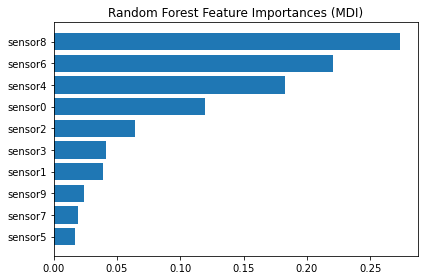

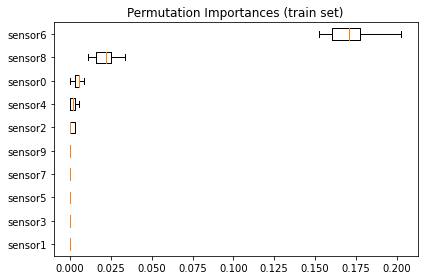

In [16]:
def delRnd(rank):
    if 'random_num' in rank: rank.remove('random_num')
    return rank

# functionized for easier access of different variations
# - with or without an "additional sensor" (randomNum=True/False)
# - random number in between 0 and 1 or drawn from Gaussian distribution
def randomNumerical(randomNum, zeroOne=True):
    df_rnd = df_copy.copy()
    
    if randomNum:
        if zeroOne:
            df_rnd['random_num'] = np.random.uniform(0,1,df_rnd.shape[0])
        else:
            rng = np.random.RandomState()
            df_rnd['random_num'] = rng.randn(df_rnd.shape[0])
    
    numerical_columns = df_rnd.columns[1:]
    
    np.random.normal(0,1,1)
    
    # declare x (sensor values) and y (class labels)
    y = df_rnd['class_label'].values
    x = df_rnd.loc[:, numerical_columns].values
    
    # create stratified test partition (10% of the cases)
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=.1,
        stratify=y)
    
    rf = Pipeline([
        ('classifier', RandomForestClassifier(n_estimators=128, n_jobs=-1)) #, random_state=42))
    ])
    
    rf.fit(x_train, y_train)
    
    # Check if model predictive performance is high enough
    print("RF train accuracy: %0.3f" % rf.score(x_train, y_train))
    print("RF test accuracy: %0.3f" % rf.score(x_test, y_test))
    
    # Tree's Feature Importance from Mean Decrease in Impurity
    feature_names = np.r_[numerical_columns]
    
    tree_feature_importances = (
        rf.named_steps['classifier'].feature_importances_)
    sorted_idx = tree_feature_importances.argsort()
    
    # return ranks
    rank_rf = list(feature_names[sorted_idx][::-1])
    rank_rf = delRnd(rank_rf)
    
    y_ticks = np.arange(0, len(feature_names))
    fig, ax = plt.subplots()
    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks.tolist())
    ax.set_yticklabels(feature_names[sorted_idx])
    ax.set_title("Random Forest Feature Importances (MDI)")
    fig.tight_layout()
    plt.show()
    
    '''
    # alternative1: permutation importances of ``rf`` on a test set. 
    result = permutation_importance(rf, x_test, y_test, n_repeats=20, n_jobs=-1)
                                    #random_state=42, n_jobs=2)
    sorted_idx = result.importances_mean.argsort()
    
    fig, ax = plt.subplots()
    ax.boxplot(result.importances[sorted_idx].T,
               vert=False, labels=feature_names[sorted_idx])
    ax.set_title("Permutation Importances (test set)")
    fig.tight_layout()
    plt.show()
    '''
    
    # alternative2: permutation importances of ``rf`` on a training set. 
    result = permutation_importance(rf, x_train, y_train, n_repeats=20)
                                    #random_state=42, n_jobs=-1)
    sorted_idx = result.importances_mean.argsort()
    # return ranks
    rank_pi = list(feature_names[sorted_idx][::-1])
    rank_pi = delRnd(rank_pi)
    
    fig, ax = plt.subplots()
    ax.boxplot(result.importances[sorted_idx].T,
               vert=False, labels=feature_names[sorted_idx])
    ax.set_title("Permutation Importances (train set)")
    fig.tight_layout()
    plt.show()
    
    return rank_rf, rank_pi

print("Original data")
rankOrigRF, rankOrigPI = randomNumerical(randomNum=False)

Random Number in between 0 and 1 added
RF train accuracy: 1.000
RF test accuracy: 1.000


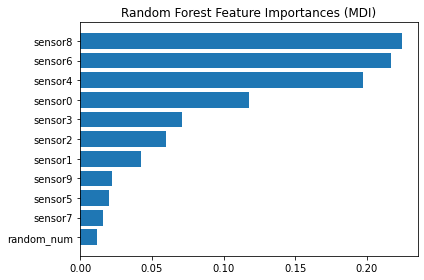

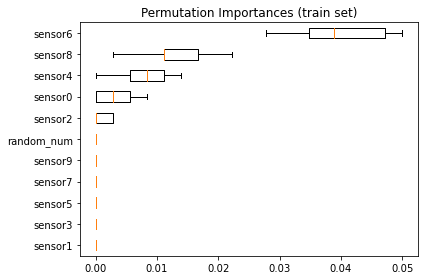

In [17]:
print("Random Number in between 0 and 1 added")
rankZeroOneRF, rankZeroOnePI = randomNumerical(randomNum=True, zeroOne=True)

Random Number from the Gaussian distribution
RF train accuracy: 1.000
RF test accuracy: 1.000


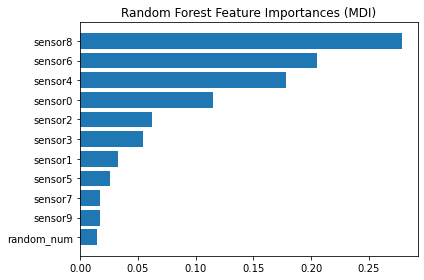

In [ ]:
print("Random Number from the Gaussian distribution")
rankGaussRF, rankGaussPI = randomNumerical(randomNum=True, zeroOne=False)

Random Forest and even more so Permutation Importance underline the importance of sensor 6 that prior methods did not reveal. Also being amongst the less correlated features

# 3) Final Results

In [ ]:
# Format results for combined_results
#LogReg
logRegRank = feature_df_sorted_abs_coef['absLogRegCoef'].index
# SelectFromModel (LinearSVC)
svcRank = [int(i) for i in list(rankingLinSVC)]
svcRank = [columns[i+1] for i in svcRank]

# combined results 
d = {'LogReg': logRegRank,
     'LinSVC': svcRank, 
     'RFsingle': rankingRF, 
     'RFmdiOrig': rankOrigRF,
     'RFmdi01': rankZeroOneRF,
     'RFmdiGauss': rankGaussRF,
     'PIOrig': rankOrigPI,
     'PI01': rankZeroOnePI,
     'PIGauss': rankGaussPI
    }
results = pd.DataFrame(data=d)

# save to csv 
results.to_csv('results.csv', index=False)

results

The above work  shows that sensors 8, 4 and 0 are valued of high importance by a all approaches.

Random Forests and Permutation importance showed very high confidence in the predictive ability of sensor 6. Thus it would be reasonable to check for performance ranking sensor 6 higher when not only wanting to rely on the tools of Logistic Regression or LinearSVC.

# 4) Scalability

While there exist ways to scale Logistic Regression, Random Forests and Permutation Importance, further optimization would need to be done.

The presented approach with SelectFromModel is highly iterative and has very low scalability. 
Similar results would probably be found with a 10-step-iteration to select the best 1,2,...,10 features using sklearn's ```SelectKBest()``` and due to an enormous reduction of iterations would be better scalable.